# Assignment 5: Two-Layer Network for Non-Linear 2D Classification

## Summary

**Hypothesis:** A two-layer neural network (one large fully connected hidden layer + a 2-neuron one-hot output layer) can classify any two-dimensional partition in a finite region, even with highly non-linear decision boundaries.

**Dataset:** Two interleaving Archimedean spirals — a classic challenging classification problem where no straight line can separate the classes. The boundary wraps around the origin multiple times, requiring the network to learn a complex, curved decision surface.

**Architecture:**
- Input: (x, y) — 2 features
- Hidden layer: 512 neurons, ReLU activation (large fully connected layer)
- Output layer: 2 neurons, softmax activation (one-hot strategy)

**Result:** The network successfully learns the spiral decision boundary and achieves high accuracy on both training and test data, supporting the hypothesis.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## Generate Two-Spirals Dataset

We create two interleaving Archimedean spirals. Each spiral winds around the origin with increasing radius. Gaussian noise is added to make the problem realistic. This is one of the most challenging 2D classification problems because the decision boundary is highly non-linear — it cannot be approximated by any straight line or simple curve.

In [2]:
np.random.seed(42)

num_samples_per_class = 1000
num = num_samples_per_class * 2
noise = 0.3

# Angles from 0.5 to 3*pi (about 1.5 full rotations)
theta = np.linspace(0.5, 3 * np.pi, num_samples_per_class)
r = theta  # Radius grows linearly with angle (Archimedean spiral)

# Spiral class 0
x0 = r * np.cos(theta) + np.random.randn(num_samples_per_class) * noise
y0 = r * np.sin(theta) + np.random.randn(num_samples_per_class) * noise
C0_samples = np.column_stack([x0, y0])

# Spiral class 1 (offset by pi radians)
x1 = r * np.cos(theta + np.pi) + np.random.randn(num_samples_per_class) * noise
y1 = r * np.sin(theta + np.pi) + np.random.randn(num_samples_per_class) * noise
C1_samples = np.column_stack([x1, y1])

print(f"Class 0 samples: {C0_samples.shape}")
print(f"Class 1 samples: {C1_samples.shape}")

# Generate separate test data
np.random.seed(99)
theta_t = np.linspace(0.5, 3 * np.pi, num_samples_per_class)
r_t = theta_t

T0_samples = np.column_stack([
    r_t * np.cos(theta_t) + np.random.randn(num_samples_per_class) * noise,
    r_t * np.sin(theta_t) + np.random.randn(num_samples_per_class) * noise
])
T1_samples = np.column_stack([
    r_t * np.cos(theta_t + np.pi) + np.random.randn(num_samples_per_class) * noise,
    r_t * np.sin(theta_t + np.pi) + np.random.randn(num_samples_per_class) * noise
])

print(f"Test class 0: {T0_samples.shape}")
print(f"Test class 1: {T1_samples.shape}")

Class 0 samples: (1000, 2)
Class 1 samples: (1000, 2)
Test class 0: (1000, 2)
Test class 1: (1000, 2)


In [3]:
# Stack into training arrays
inputs = np.vstack((C0_samples, C1_samples)).astype(np.float32)
targets = np.concatenate([np.zeros(num_samples_per_class),
                          np.ones(num_samples_per_class)]).astype(np.float32)

# Stack into testing arrays
Tinputs = np.vstack((T0_samples, T1_samples)).astype(np.float32)
Ttargets = np.concatenate([np.zeros(num_samples_per_class),
                           np.ones(num_samples_per_class)]).astype(np.float32)

print(f"Training: {inputs.shape}, {targets.shape}")
print(f"Testing:  {Tinputs.shape}, {Ttargets.shape}")

Training: (2000, 2), (2000,)
Testing:  (2000, 2), (2000,)


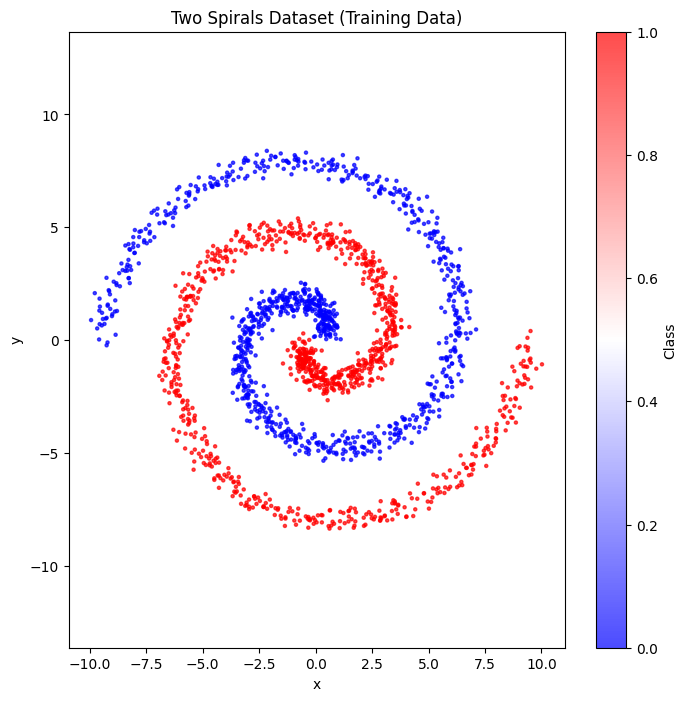

In [4]:
# Plot training data
plt.figure(figsize=(8, 8))
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets, cmap='bwr', s=5, alpha=0.7)
plt.title('Two Spirals Dataset (Training Data)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.colorbar(label='Class')
plt.show()

## Build and Train the Two-Layer Model

The model uses:
- **Hidden layer:** 512 neurons with ReLU activation. This large layer gives the network enough capacity to carve out the complex spiral boundary using piecewise-linear regions.
- **Output layer:** 2 neurons with softmax activation (one-hot encoding strategy). Neuron 0 fires for class 0, neuron 1 fires for class 1.

We use the Adam optimizer and sparse categorical cross-entropy loss (appropriate for integer class labels with softmax output).

In [5]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(2, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(inputs, targets,
                    epochs=200,
                    batch_size=64,
                    validation_data=(Tinputs, Ttargets))

Epoch 1/200


 1/32 ━━━━━━━━━━━━━━━━━━━━ 8s 268ms/step - accuracy: 0.5156 - loss: 0.7005

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6340 - loss: 0.6647 - val_accuracy: 0.6405 - val_loss: 0.6546


Epoch 2/200


 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7031 - loss: 0.6260

...

 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0035

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9995 - loss: 0.0060 - val_accuracy: 0.9980 - val_loss: 0.0113


Epoch 200/200


 1/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0069

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9995 - loss: 0.0059 - val_accuracy: 0.9980 - val_loss: 0.0110


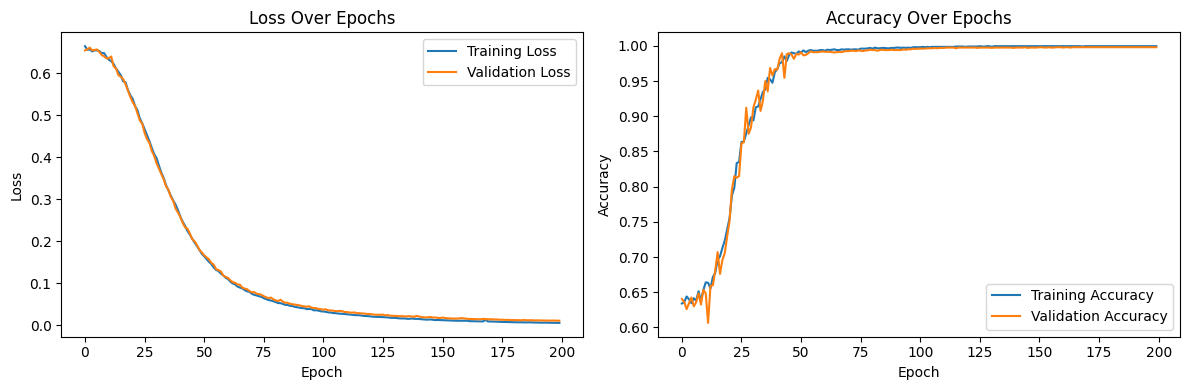

In [6]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Evaluate on Test Data

In [7]:
test_loss, test_acc = model.evaluate(Tinputs, Ttargets)
print(f"Test accuracy: {test_acc:.4f}")

 1/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9375 - loss: 0.2972

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 324us/step - accuracy: 0.9980 - loss: 0.0110


Test accuracy: 0.9980


In [8]:
# Check a few predictions
sample_predictions = model.predict(Tinputs[:10])
print("Predictions (first 10 test samples):")
for i in range(10):
    pred_class = sample_predictions[i].argmax()
    true_class = int(Ttargets[i])
    print(f"  Sample {i}: predicted={pred_class}, actual={true_class}, "
          f"probabilities={sample_predictions[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


Predictions (first 10 test samples):
  Sample 0: predicted=0, actual=0, probabilities=[0.98798656 0.01201342]
  Sample 1: predicted=0, actual=0, probabilities=[0.90792596 0.09207398]
  Sample 2: predicted=0, actual=0, probabilities=[0.98196167 0.01803836]
  Sample 3: predicted=0, actual=0, probabilities=[0.9886795  0.01132049]
  Sample 4: predicted=0, actual=0, probabilities=[0.857768   0.14223205]
  Sample 5: predicted=0, actual=0, probabilities=[0.6879567  0.31204334]
  Sample 6: predicted=0, actual=0, probabilities=[0.99700606 0.00299386]
  Sample 7: predicted=0, actual=0, probabilities=[0.6240553  0.37594458]
  Sample 8: predicted=0, actual=0, probabilities=[0.9987771  0.00122291]
  Sample 9: predicted=1, actual=0, probabilities=[0.00161463 0.9983854 ]


## Decision Boundary Visualization

We sample a dense grid of points across the input space and color each point by the model's predicted class. This reveals the learned decision boundary — the complex, curved surface that separates the two spiral classes.

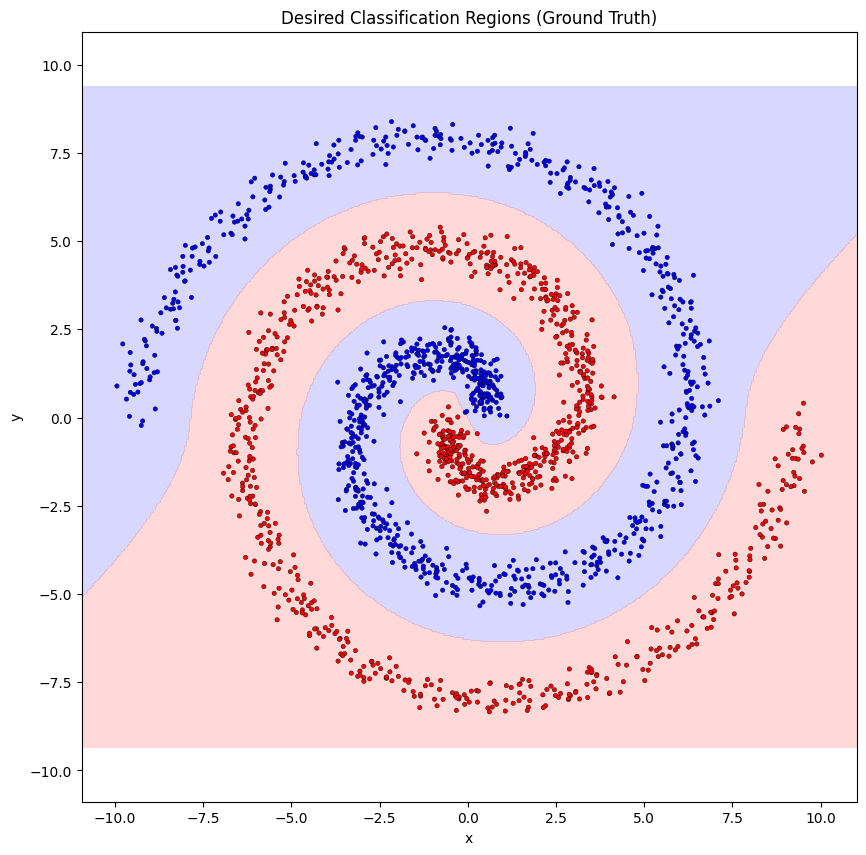

In [9]:
# Desired (ground truth) classification regions
# Use nearest-neighbor on the noiseless spiral curves to determine ground truth class
from scipy.spatial import cKDTree

# Dense noiseless spiral points
theta_dense = np.linspace(0.5, 3 * np.pi, 5000)
r_dense = theta_dense
spiral0 = np.column_stack([r_dense * np.cos(theta_dense), r_dense * np.sin(theta_dense)])
spiral1 = np.column_stack([r_dense * np.cos(theta_dense + np.pi), r_dense * np.sin(theta_dense + np.pi)])

tree0 = cKDTree(spiral0)
tree1 = cKDTree(spiral1)

# Create grid
x_min, x_max = inputs[:, 0].min() - 1, inputs[:, 0].max() + 1
y_min, y_max = inputs[:, 1].min() - 1, inputs[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500), np.linspace(y_min, y_max, 500))
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

d0, _ = tree0.query(grid_pts)
d1, _ = tree1.query(grid_pts)
desired_class = (d1 < d0).astype(float).reshape(xx.shape)

plt.figure(figsize=(10, 10))
plt.contourf(xx, yy, desired_class, levels=1, cmap='bwr', alpha=0.3)
plt.scatter(inputs[:, 0], inputs[:, 1],
            c=targets, cmap='bwr', s=10, edgecolors='black', linewidths=0.3)
plt.title('Desired Classification Regions (Ground Truth)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()

   1/6250 ━━━━━━━━━━━━━━━━━━━━ 1:15 12ms/step

 302/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 166us/step 

 607/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 165us/step

 914/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 164us/step

1222/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 164us/step

...

5271/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 171us/step

5561/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 171us/step

5868/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 171us/step

6179/6250 ━━━━━━━━━━━━━━━━━━━━ 0s 170us/step

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 1s 171us/step


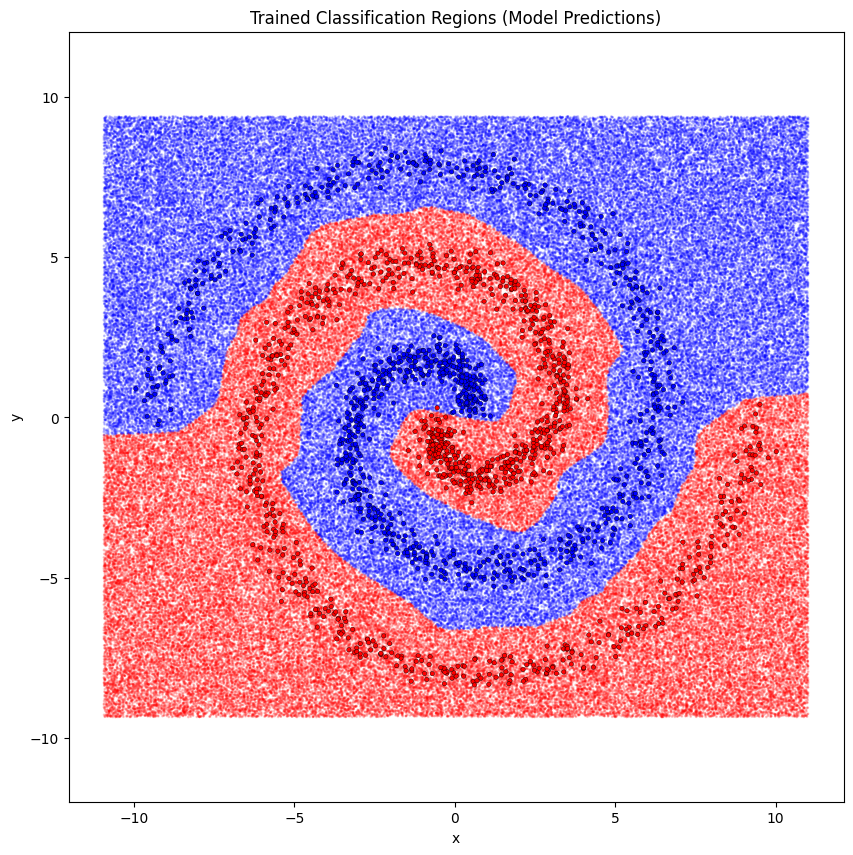

In [10]:
# Trained classification regions
num_grid = 200000

x_min, x_max = inputs[:, 0].min() - 1, inputs[:, 0].max() + 1
y_min, y_max = inputs[:, 1].min() - 1, inputs[:, 1].max() + 1

grid_x = np.random.uniform(x_min, x_max, num_grid)
grid_y = np.random.uniform(y_min, y_max, num_grid)
grid_inputs = np.column_stack([grid_x, grid_y]).astype(np.float32)

grid_predictions = model.predict(grid_inputs)

plt.figure(figsize=(10, 10))
plt.scatter(grid_inputs[:, 0], grid_inputs[:, 1],
            c=grid_predictions[:, 1] > 0.5, cmap='bwr', s=1, alpha=0.2)
plt.scatter(inputs[:, 0], inputs[:, 1],
            c=targets, cmap='bwr', s=10, edgecolors='black', linewidths=0.3)
plt.title('Trained Classification Regions (Model Predictions)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.show()